In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as functional
import torch.optim as optim
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.utils import make_grid
from torch.autograd import Variable
device = 'cuda' if torch.cuda.is_available() else 'cpu' #imports

In [3]:
train_dataset = MNIST('data', transform=transforms.ToTensor(), train=True, download=False)
test_dataset = MNIST('data', transform=transforms.ToTensor(), train=False, download=False) #dados de treino e teste

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) #embaralhando

In [4]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1) #camadas de convolucao
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc21 = nn.Linear(256, 20)
        self.fc22 = nn.Linear(256, 20)
        self.fc3 = nn.Linear(20, 256)
        self.fc4 = nn.Linear(256, 64 * 7 * 7) #camadas totalmente conectadas, gera log, pega media e recosntroi
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1) #reconstroi a imagem

    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x)) #camadas de convolucao
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        mu = self.fc21(x) #clcula media
        logvar = self.fc22(x)
        return mu, logvar #faz o encode da imagem achatando

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = Variable(torch.randn(std.size()).to(device))
            return eps.mul(std).add_(mu) #durante o treinamento pega o desvio padrao e abaixa a qualidade
        else:
            return mu

    def decode(self, z): 
        z = F.relu(self.fc3(z))
        z = F.relu(self.fc4(z))
        z = z.view(z.size(0), 64, 7, 7)
        z = F.relu(self.deconv1(z))
        z = torch.sigmoid(self.deconv2(z))
        return z #recontroi a imagem expandindo o vetor e vai remodelando

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        z = self.decode(z)
        return z, mu, logvar #fluxo da rede

In [5]:
def loss_function(recon_x, x, mean, log_var):
    RECON = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1+log_var-mean.pow(2) - log_var.exp())
    return RECON + KLD, RECON, KLD #funcao q pega o erro

In [6]:
def train_batch(data,model,optimizer,loss_function): #
    model.train() #trino
    data = data.to(device) #coloca no gpu ou cpu
    optimizer.zero_grad() #zera pra proxima etapa
    recon_batch, mean, log_var = model(data)
    loss,mse,kld = loss_function(recon_batch, data, mean, log_var)
    loss.backward()
    optimizer.step() #faz a atualuizacao de peso
    return loss, mse, kld, log_var.mean(), mean.mean()

@torch.no_grad()
def validate_batch(data,model,loss_function):
    model.eval() #coloca em teste
    data = data.to(device) #coloca na gpu ou cpu
    recon,mean,log_var = model(data)
    loss, mse, kld = loss_function(recon,data,mean,log_var) #pega o erro
    return loss, mse, kld, log_var.mean(), mean.mean() 

EPOCH: 1.000  train_kld: 374.965  train_recon: 2336.917  train_loss: 2711.882  val_recon: 1271.910  val_loss: 1837.229  train_log_var: -0.552  val_kld: 565.320  val_mean: -0.011  val_log_var: -0.871  train_mean: 0.004  (7.89s - 71.00s remaining)
EPOCH: 2.000  train_kld: 620.812  train_recon: 1420.926  train_loss: 2041.738  val_recon: 1042.074  val_loss: 1701.030  train_log_var: -0.962  val_kld: 658.956  val_mean: -0.008  val_log_var: -1.032  train_mean: 0.000  (14.69s - 58.76s remaining)
EPOCH: 3.000  train_kld: 663.714  train_recon: 1277.107  train_loss: 1940.821  val_recon: 947.325  val_loss: 1624.182  train_log_var: -1.033  val_kld: 676.857  val_mean: -0.007  val_log_var: -1.058  train_mean: -0.001  (21.85s - 50.98s remaining)
EPOCH: 4.000  train_kld: 692.148  train_recon: 1201.860  train_loss: 1894.009  val_recon: 892.125  val_loss: 1596.455  train_log_var: -1.080  val_kld: 704.330  val_mean: 0.005  val_log_var: -1.094  train_mean: -0.001  (27.88s - 41.82s remaining)
EPOCH: 5.000  

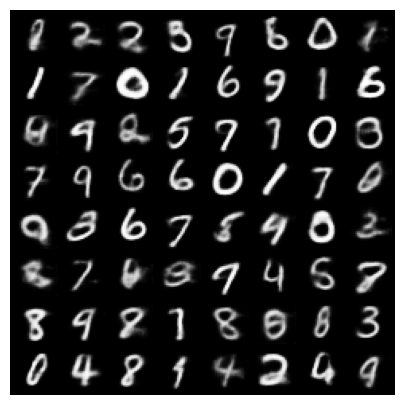

In [7]:
n_epochs = 10 #epochs
log = Report(n_epochs)
vae = VAE().to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)

for epoch in range(n_epochs): #vai pra todas as epochs
    N = len(train_loader)
    for batch_idx, (data, _) in enumerate(train_loader): #todos os batchs
        loss, recon, kld, log_var, mean = train_batch(data, vae, optimizer, loss_function)
        pos = epoch + (1+batch_idx)/N #treina o lote e pega a posicao
        log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, train_log_var=log_var, train_mean=mean, end='\r') #guar as metricas
        
    N = len(test_loader) #teste
    for batch_idx, (data, _) in enumerate(test_loader):
        loss, recon, kld, log_var, mean = validate_batch(data, vae, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, val_log_var=log_var, val_mean=mean, end='\r') #testa os lotes
        
    log.report_avgs(epoch+1) #medias da epoca
with torch.no_grad(): 
    z = torch.randn(64, 20).to(device)
    sample = vae.decode(z).to(device)
    images = make_grid(sample.view(64, 1, 28, 28)).permute(1,2,0)
    show(images) #exibe as imagens